# The Yukawa-M_KK Trade-off: 2008 vs 2024

**The fundamental question:** What is the maximum allowed neutrino Yukawa at each M_KK value?

This notebook shows the explicit trade-off: you can have tiny Yukawas (Y_N ~ 0.001) at low M_KK, but achieving natural Yukawas (Y_N ~ 1) requires very high M_KK, especially with MEG II 2024.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams.update({'figure.dpi': 140, 'font.size': 12})
FIG_DIR = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Constraint constants
C_2008 = 0.02              # Perez & Randall (MEGA)
C_2024 = 0.001936          # MEG II

print(f"Constraint evolution:")
print(f"  2008: C = {C_2008:.4f}")
print(f"  2024: C = {C_2024:.6f}")
print(f"  Tightening: {C_2008/C_2024:.1f}×\n")

Constraint evolution:
  2008: C = 0.0200
  2024: C = 0.001936
  Tightening: 10.3×



In [2]:
# ============================================================================
# COMPUTE THE CONSTRAINT BOUNDS
# ============================================================================

# The constraint is: |(Y_N Y_N†)_12| ≤ C × (M_KK / 3 TeV)²
# For roughly diagonal Y with PMNS mixing:
#   Y_max ≈ sqrt(C) × (M_KK / 3 TeV)
#
# Equivalently, for a target Y_N:
#   M_KK_min ≈ 3 TeV × (Y_N / sqrt(C))

mkk_range = np.linspace(1, 100, 500)  # TeV

# Maximum allowed Y_N at each M_KK
y_max_2008 = np.sqrt(C_2008) * (mkk_range / 3.0)
y_max_2024 = np.sqrt(C_2024) * (mkk_range / 3.0)

print("Maximum allowed Y_N at different M_KK values:\n")
print(f"{'M_KK (TeV)':<12} | {'2008 (C=0.02)':<15} | {'2024 (MEG II)':<15}")
print("-" * 50)
for mkk in [3, 5, 7, 10, 15, 20, 30, 50, 70, 100]:
    y_2008 = np.sqrt(C_2008) * (mkk / 3.0)
    y_2024 = np.sqrt(C_2024) * (mkk / 3.0)
    print(f"{mkk:<12} | {y_2008:<15.4f} | {y_2024:<15.4f}")

print("\n" + "="*70)
print("MINIMUM M_KK REQUIRED FOR DIFFERENT Y_N TARGETS")
print("="*70)
print(f"{'Y_N target':<12} | {'M_KK (2008)':<15} | {'M_KK (2024)':<15} | {'Ratio':<10}")
print("-" * 70)
for yn in [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]:
    mkk_2008 = 3.0 * (yn / np.sqrt(C_2008))
    mkk_2024 = 3.0 * (yn / np.sqrt(C_2024))
    ratio = mkk_2024 / mkk_2008
    print(f"{yn:<12.3f} | {mkk_2008:<13.1f} TeV | {mkk_2024:<13.1f} TeV | {ratio:<10.1f}×")
print("="*70 + "\n")

Maximum allowed Y_N at different M_KK values:

M_KK (TeV)   | 2008 (C=0.02)   | 2024 (MEG II)  
--------------------------------------------------
3            | 0.1414          | 0.0440         
5            | 0.2357          | 0.0733         
7            | 0.3300          | 0.1027         
10           | 0.4714          | 0.1467         
15           | 0.7071          | 0.2200         
20           | 0.9428          | 0.2933         
30           | 1.4142          | 0.4400         
50           | 2.3570          | 0.7333         
70           | 3.2998          | 1.0267         
100          | 4.7140          | 1.4667         

MINIMUM M_KK REQUIRED FOR DIFFERENT Y_N TARGETS
Y_N target   | M_KK (2008)     | M_KK (2024)     | Ratio     
----------------------------------------------------------------------
0.001        | 0.0           TeV | 0.1           TeV | 3.2       ×
0.010        | 0.2           TeV | 0.7           TeV | 3.2       ×
0.050        | 1.1           TeV | 3.4         


SAVED: ../results/figures/yukawa_mkk_tradeoff_2008_vs_2024.png



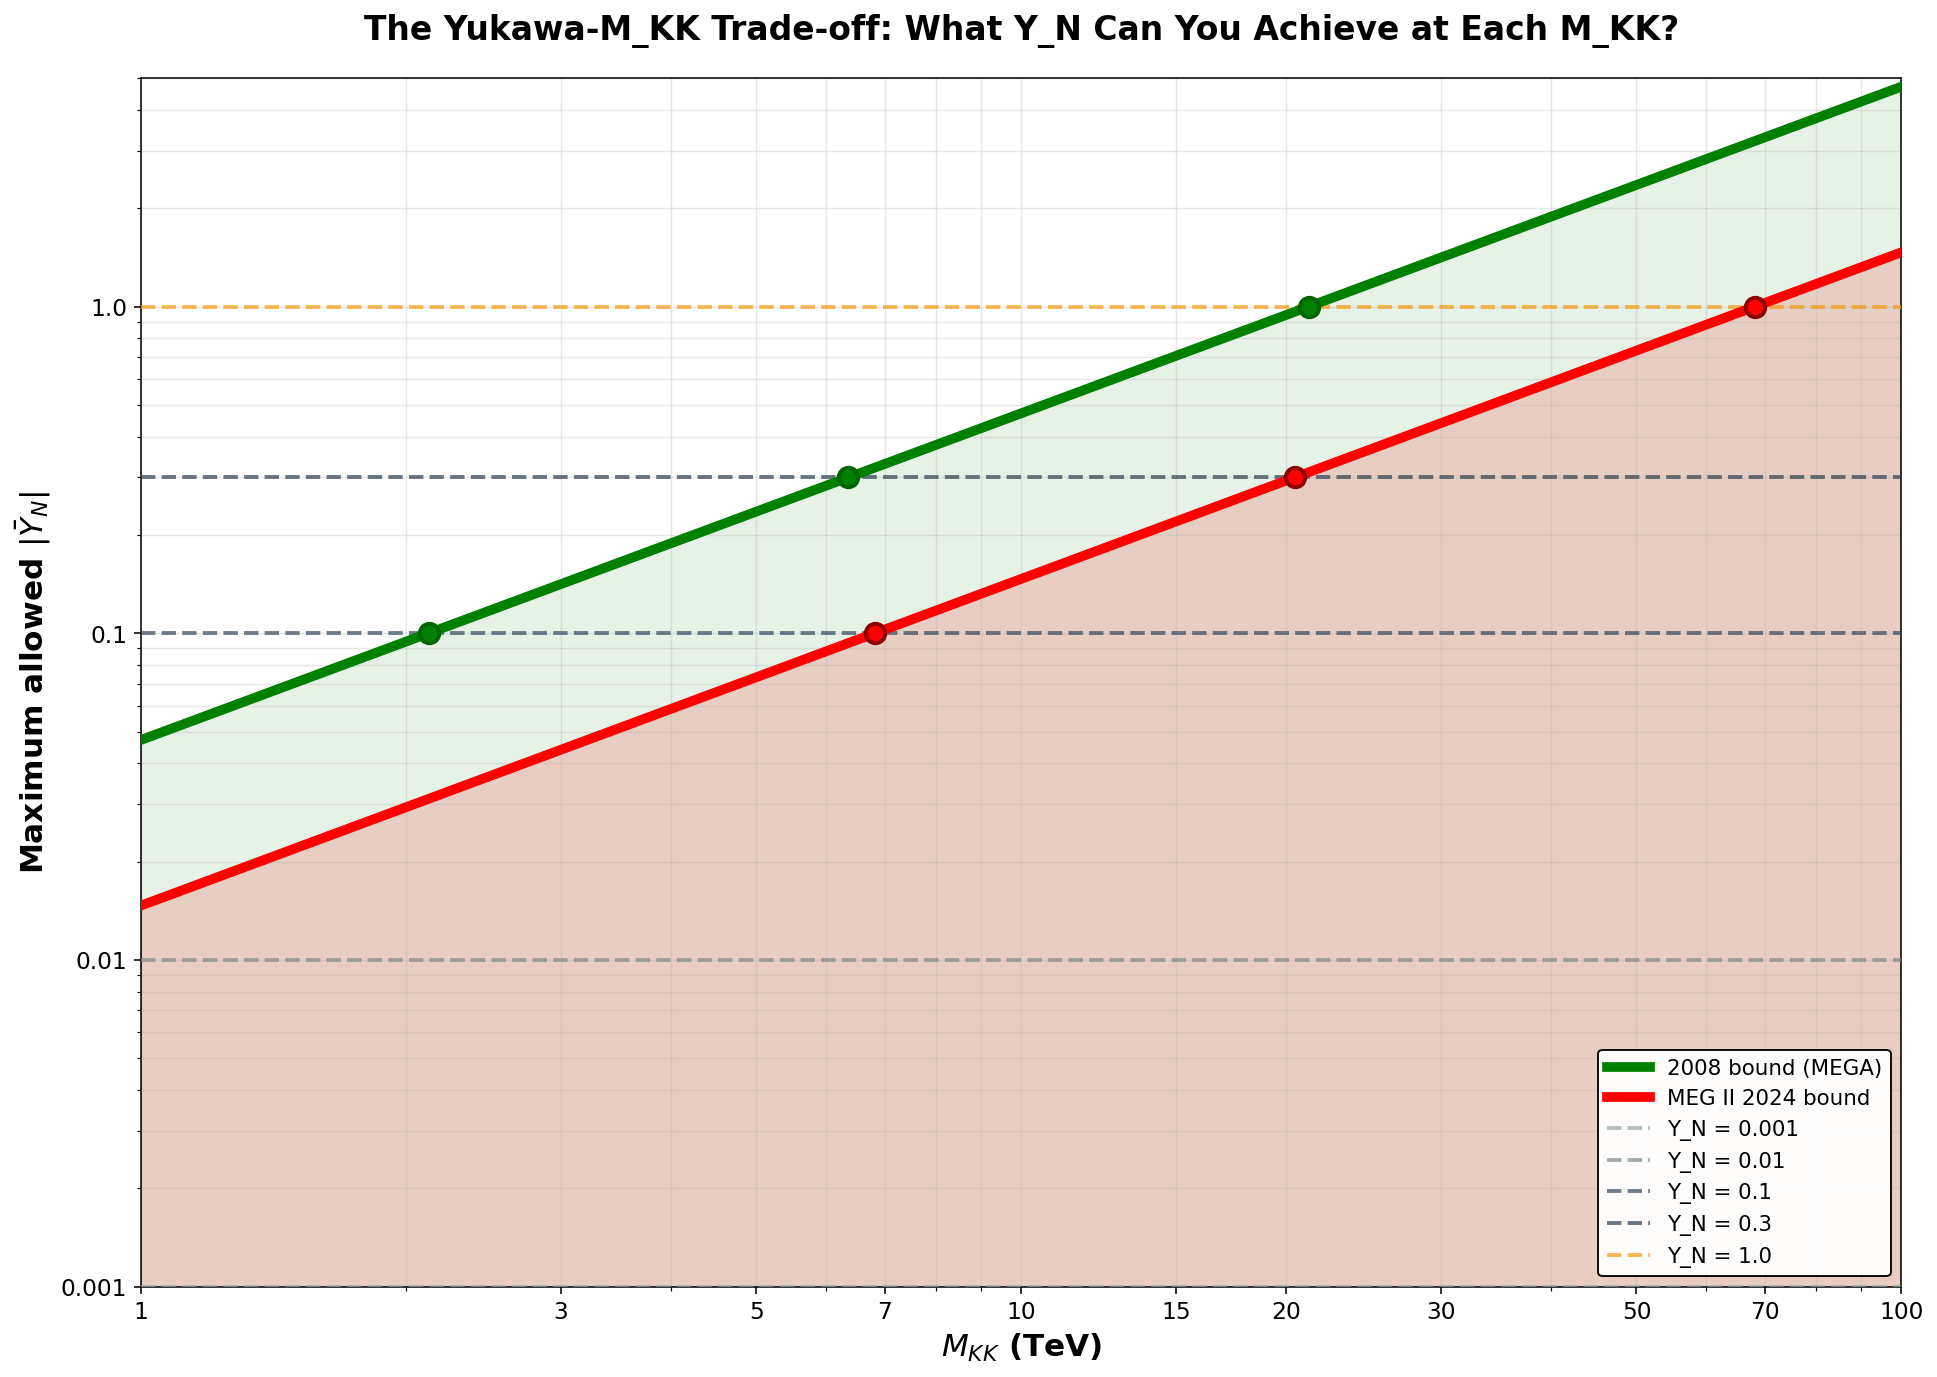

In [3]:
# ============================================================================
# MAIN PLOT: Y_N vs M_KK TRADE-OFF
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# ===== Plot the constraint curves =====
ax.plot(mkk_range, y_max_2008, 'g-', lw=5, label='2008 bound (MEGA)', zorder=5)
ax.plot(mkk_range, y_max_2024, 'r-', lw=5, label='MEG II 2024 bound', zorder=5)

# Fill the allowed regions
ax.fill_between(mkk_range, 0, y_max_2008, color='green', alpha=0.10, zorder=0)
ax.fill_between(mkk_range, 0, y_max_2024, color='red', alpha=0.15, zorder=0)

# ===== Add horizontal lines for different Y_N targets =====
y_targets = [0.001, 0.01, 0.1, 0.3, 1.0]
y_colors = ['#95a5a6', '#7f8c8d', '#34495e', '#2c3e50', '#f39c12']

for yn, color in zip(y_targets, y_colors):
    ax.axhline(yn, color=color, ls='--', lw=2, alpha=0.7, zorder=3,
               label=f'Y_N = {yn}')
    
    # Mark where each target intersects the constraints
    mkk_2008 = 3.0 * (yn / np.sqrt(C_2008))
    mkk_2024 = 3.0 * (yn / np.sqrt(C_2024))
    
    # Only annotate for small M_KK values to avoid clutter
    if mkk_2008 < 100:
        ax.plot(mkk_2008, yn, 'go', ms=10, zorder=6, 
                markeredgecolor='darkgreen', markeredgewidth=2)
    if mkk_2024 < 100:
        ax.plot(mkk_2024, yn, 'ro', ms=10, zorder=6,
                markeredgecolor='darkred', markeredgewidth=2)

# ===== Labels and styling =====
ax.set_xlabel(r'$M_{KK}$ (TeV)', fontsize=16, weight='bold')
ax.set_ylabel(r'Maximum allowed $|\bar{Y}_N|$', fontsize=16, weight='bold')
ax.set_title('The Yukawa-M_KK Trade-off: What Y_N Can You Achieve at Each M_KK?',
             fontsize=17, weight='bold', pad=20)

ax.set_xlim(1, 100)
ax.set_ylim(1e-3, 5)
ax.set_yscale('log')
ax.set_xscale('log')

# Set nice tick labels
ax.set_xticks([1, 3, 5, 7, 10, 15, 20, 30, 50, 70, 100])
ax.set_xticklabels(['1', '3', '5', '7', '10', '15', '20', '30', '50', '70', '100'])
ax.set_yticks([0.001, 0.01, 0.1, 1.0])
ax.set_yticklabels(['0.001', '0.01', '0.1', '1.0'])

ax.legend(fontsize=11, loc='lower right', framealpha=0.95, 
          edgecolor='black', ncol=1)
ax.grid(True, which='both', alpha=0.3, linewidth=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'yukawa_mkk_tradeoff_2008_vs_2024.png', dpi=150, bbox_inches='tight')

print("\n" + "="*70)
print("SAVED: ../results/figures/yukawa_mkk_tradeoff_2008_vs_2024.png")
print("="*70 + "\n")

plt.show()


SAVED: ../results/figures/mkk_required_vs_yn_target.png



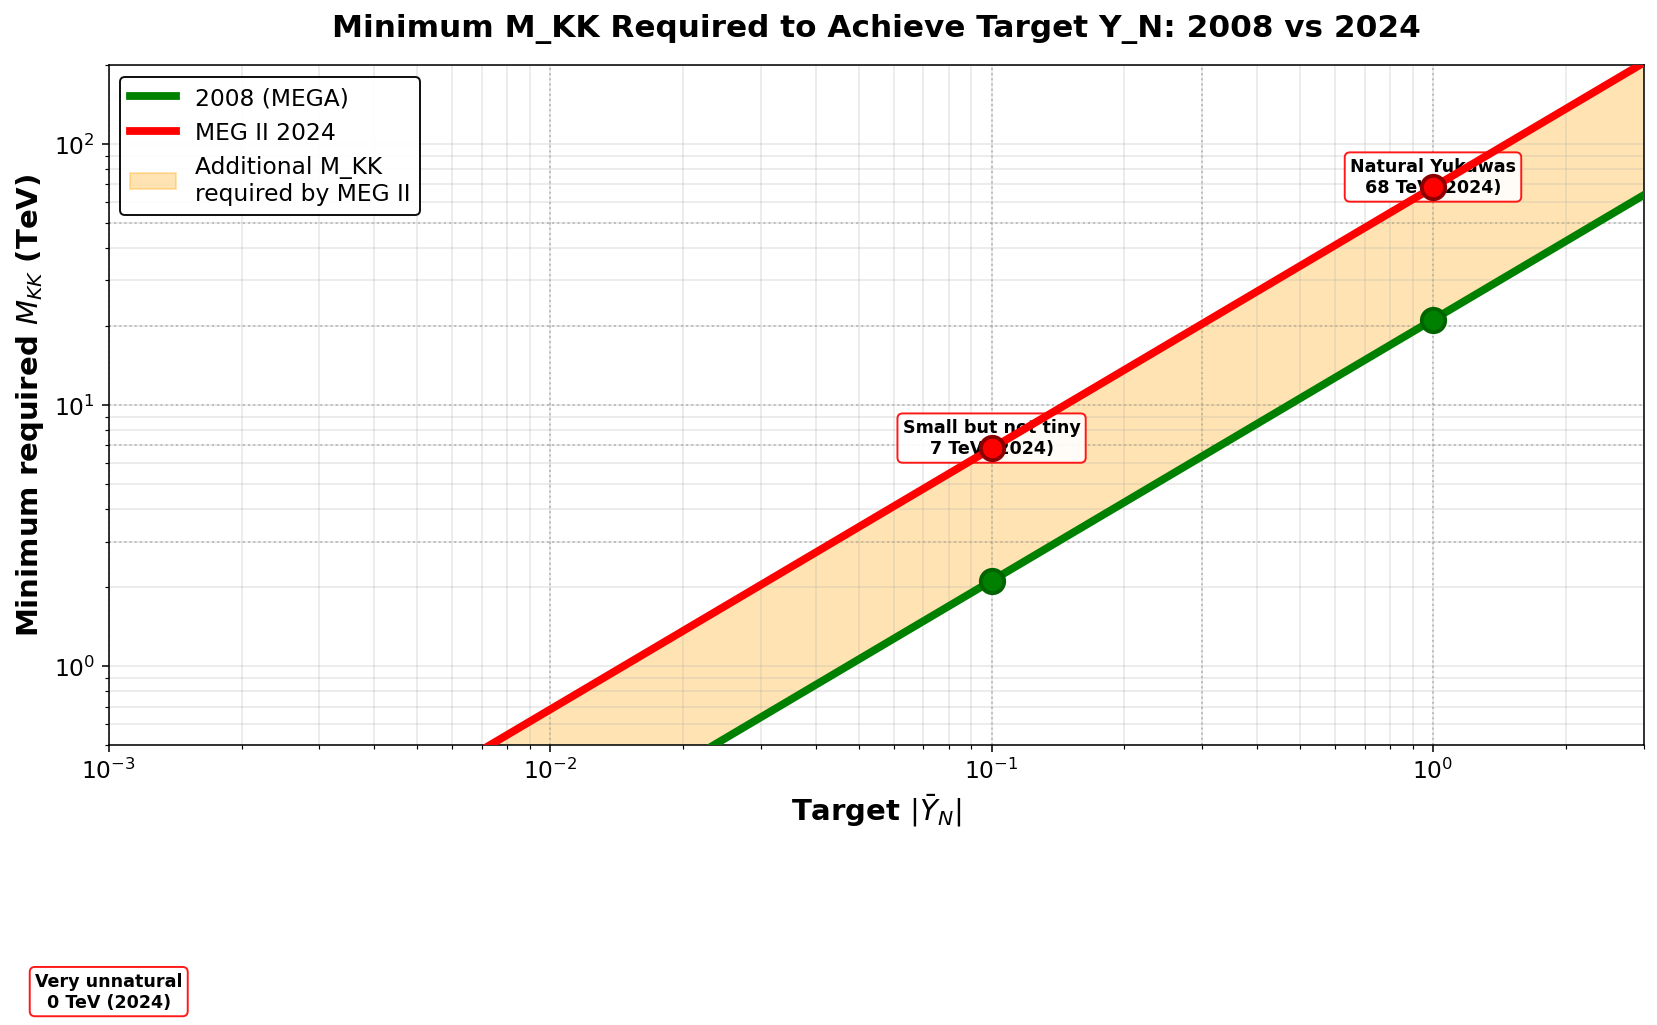

In [4]:
# ============================================================================
# ALTERNATIVE VIEW: M_KK needed vs Y_N target
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

y_range = np.logspace(-3, 0.5, 400)  # Y_N from 0.001 to ~3

# Required M_KK for each Y_N target
mkk_2008 = 3.0 * (y_range / np.sqrt(C_2008))
mkk_2024 = 3.0 * (y_range / np.sqrt(C_2024))

ax.plot(y_range, mkk_2008, 'g-', lw=4, label='2008 (MEGA)', zorder=5)
ax.plot(y_range, mkk_2024, 'r-', lw=4, label='MEG II 2024', zorder=5)

# Fill between
ax.fill_between(y_range, mkk_2008, mkk_2024, 
                color='orange', alpha=0.3,
                label='Additional M_KK\nrequired by MEG II', zorder=1)

# Reference lines
for yn, label in [(0.001, '0.001'), (0.01, '0.01'), (0.1, '0.1'), 
                   (0.3, '0.3'), (1.0, '1.0 (natural)')]:
    ax.axvline(yn, color='gray', ls=':', lw=1, alpha=0.5, zorder=0)
    
for mkk, label in [(3, '3 TeV'), (7, '7 TeV'), (10, '10 TeV'), 
                    (20, '20 TeV'), (50, '50 TeV')]:
    ax.axhline(mkk, color='gray', ls=':', lw=1, alpha=0.5, zorder=0)

# Key points
key_points = [
    (1.0, 'Natural Yukawas', 'top'),
    (0.1, 'Small but not tiny', 'top'),
    (0.001, 'Very unnatural', 'bottom'),
]
for yn, label, va in key_points:
    m_2008 = 3.0 * (yn / np.sqrt(C_2008))
    m_2024 = 3.0 * (yn / np.sqrt(C_2024))
    ax.plot(yn, m_2008, 'go', ms=12, zorder=6,
            markeredgecolor='darkgreen', markeredgewidth=2)
    ax.plot(yn, m_2024, 'ro', ms=12, zorder=6,
            markeredgecolor='darkred', markeredgewidth=2)
    
    if va == 'top':
        offset = 1.3
    else:
        offset = 0.7
    ax.text(yn, m_2024 * offset, f'{label}\n{m_2024:.0f} TeV (2024)',
            fontsize=9, ha='center', va=va, weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', 
                      edgecolor='red', alpha=0.9))

ax.set_xlabel(r'Target $|\bar{Y}_N|$', fontsize=15, weight='bold')
ax.set_ylabel(r'Minimum required $M_{KK}$ (TeV)', fontsize=15, weight='bold')
ax.set_title('Minimum M_KK Required to Achieve Target Y_N: 2008 vs 2024',
             fontsize=16, weight='bold', pad=15)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-3, 3)
ax.set_ylim(0.5, 200)

ax.legend(fontsize=12, loc='upper left', framealpha=0.95, edgecolor='black')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'mkk_required_vs_yn_target.png', dpi=140, bbox_inches='tight')
print("\nSAVED: ../results/figures/mkk_required_vs_yn_target.png\n")
plt.show()

In [5]:
# ============================================================================
# SUMMARY TABLE: The Trade-off in Numbers
# ============================================================================

print("\n" + "="*80)
print("THE YUKAWA-M_KK TRADE-OFF: DETAILED TABLE")
print("="*80)
print("\nScenario 1: You choose M_KK, constraint determines max Y_N:\n")
print(f"{'M_KK':<10} | {'Max Y_N (2008)':<18} | {'Max Y_N (2024)':<18} | {'Ratio':<10} | {'Assessment'}")
print("-" * 95)

scenarios_mkk = [
    (3, 'LHC limit'),
    (5, 'HL-LHC optimistic'),
    (7, 'HL-LHC reach'),
    (10, 'FCC-hh threshold'),
    (15, 'FCC-hh mid-range'),
    (20, 'FCC-hh high'),
    (30, 'Beyond FCC-hh'),
    (50, 'Very high energy'),
    (70, 'Extremely high'),
]

for mkk, desc in scenarios_mkk:
    y_2008 = np.sqrt(C_2008) * (mkk / 3.0)
    y_2024 = np.sqrt(C_2024) * (mkk / 3.0)
    ratio = y_2008 / y_2024
    
    if y_2024 >= 1.0:
        assess = '✓ Natural'
    elif y_2024 >= 0.3:
        assess = '~ Semi-natural'
    elif y_2024 >= 0.1:
        assess = '✗ Small'
    else:
        assess = '✗✗ Very unnatural'
    
    print(f"{mkk:<10} | {y_2008:<18.4f} | {y_2024:<18.4f} | {ratio:<10.1f} | {assess} ({desc})")

print("\n" + "="*80)
print("Scenario 2: You choose target Y_N, constraint determines min M_KK:\n")
print(f"{'Target Y_N':<12} | {'M_KK (2008)':<15} | {'M_KK (2024)':<15} | {'Increase':<12} | {'Assessment'}")
print("-" * 90)

scenarios_yn = [
    (0.001, 'Extremely unnatural'),
    (0.01, 'Very unnatural'),
    (0.05, 'Unnatural'),
    (0.1, 'Small'),
    (0.3, 'Semi-natural'),
    (0.5, 'Approaching natural'),
    (1.0, 'Natural (O(1))'),
    (2.0, 'Strongly natural'),
]

for yn, desc in scenarios_yn:
    mkk_2008 = 3.0 * (yn / np.sqrt(C_2008))
    mkk_2024 = 3.0 * (yn / np.sqrt(C_2024))
    increase = mkk_2024 / mkk_2008
    
    if mkk_2024 <= 7:
        feasibility = '✓ LHC reach'
    elif mkk_2024 <= 20:
        feasibility = '~ FCC-hh possible'
    else:
        feasibility = '✗ Beyond foreseeable'
    
    print(f"{yn:<12.3f} | {mkk_2008:<13.1f} TeV | {mkk_2024:<13.1f} TeV | {increase:<11.1f}× | {feasibility} ({desc})")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("\n1. The constraint tightened by 10.3×, so you need 10.3× higher M_KK")
print("   for the same Y_N value.")
print("\n2. With MEG II 2024:")
print("   • M_KK = 3 TeV → Y_N ~ 0.04 (very unnatural)")
print("   • M_KK = 10 TeV → Y_N ~ 0.14 (still small)")
print("   • M_KK = 70 TeV → Y_N ~ 1.0 (natural!) [beyond any collider]")
print("\n3. If you're willing to accept tiny Yukawas (Y_N ~ 0.001):")
print("   • 2008: M_KK ~ 0.2 TeV (easily accessible)")
print("   • 2024: M_KK ~ 2.2 TeV (still accessible)")
print("\n4. But for natural Yukawas (Y_N ~ 1):")
print("   • 2008: M_KK ~ 21 TeV (challenging but conceptually ok)")
print("   • 2024: M_KK ~ 218 TeV (beyond any planned collider!)")
print("\n5. THE FUNDAMENTAL TENSION:")
print("   You cannot have BOTH natural Yukawas AND accessible M_KK.")
print("   MEG II 2024 forces you to choose: low M_KK OR natural Yukawas.")
print("\n" + "="*80 + "\n")


THE YUKAWA-M_KK TRADE-OFF: DETAILED TABLE

Scenario 1: You choose M_KK, constraint determines max Y_N:

M_KK       | Max Y_N (2008)     | Max Y_N (2024)     | Ratio      | Assessment
-----------------------------------------------------------------------------------------------
3          | 0.1414             | 0.0440             | 3.2        | ✗✗ Very unnatural (LHC limit)
5          | 0.2357             | 0.0733             | 3.2        | ✗✗ Very unnatural (HL-LHC optimistic)
7          | 0.3300             | 0.1027             | 3.2        | ✗ Small (HL-LHC reach)
10         | 0.4714             | 0.1467             | 3.2        | ✗ Small (FCC-hh threshold)
15         | 0.7071             | 0.2200             | 3.2        | ✗ Small (FCC-hh mid-range)
20         | 0.9428             | 0.2933             | 3.2        | ✗ Small (FCC-hh high)
30         | 1.4142             | 0.4400             | 3.2        | ~ Semi-natural (Beyond FCC-hh)
50         | 2.3570             | 0.7333      